In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import pickle

In [57]:
df = pd.read_csv("car data.csv")

df.head()

,Car_Name,Year,Selling_Price,Present_Price,Kms_Driven,Fuel_Type,Seller_Type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [58]:
print("Shape:", df.shape)
df.info()

Shape: (301, 9)
<class 'pandas.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    str    
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Kms_Driven     301 non-null    int64  
 5   Fuel_Type      301 non-null    str    
 6   Seller_Type    301 non-null    str    
 7   Transmission   301 non-null    str    
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 21.3 KB


In [59]:
df.describe()

,Year,Selling_Price,Present_Price,Kms_Driven,Owner
count,301.000000,301.000000,301.000000,301.000000,301.000000
mean,2013.627907,4.661296,7.628472,36947.205980,0.043189
std,2.891554,5.082812,8.644115,38886.883882,0.247915
min,2003.000000,0.100000,0.320000,500.000000,0.000000
25%,2012.000000,0.900000,1.200000,15000.000000,0.000000
50%,2014.000000,3.600000,6.400000,32000.000000,0.000000
75%,2016.000000,6.000000,9.900000,48767.000000,0.000000
max,2018.000000,35.000000,92.600000,500000.000000,3.000000


In [60]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Missing values:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Kms_Driven       0
Fuel_Type        0
Seller_Type      0
Transmission     0
Owner            0
dtype: int64

Duplicate rows: 2


In [61]:
df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (299, 9)


In [62]:
for col in ["Fuel_Type", "Seller_Type", "Transmission"]:
    df[col] = df[col].astype(str).str.strip().str.title()

print(df["Fuel_Type"].unique())
print(df["Seller_Type"].unique())
print(df["Transmission"].unique())

<StringArray>
['Petrol', 'Diesel', 'Cng']
Length: 3, dtype: str
<StringArray>
['Dealer', 'Individual']
Length: 2, dtype: str
<StringArray>
['Manual', 'Automatic']
Length: 2, dtype: str


In [63]:
current_year = 2026

df["Car_Age"] = current_year - df["Year"]
df["Brand"] = df["Car_Name"].str.split().str[0].str.title()


df[["Car_Name", "Year", "Car_Age", "Brand"]].head()




,Car_Name,Year,Car_Age,Brand
0,ritz,2014,12,Ritz
1,sx4,2013,13,Sx4
2,ciaz,2017,9,Ciaz
3,wagon r,2011,15,Wagon
4,swift,2014,12,Swift


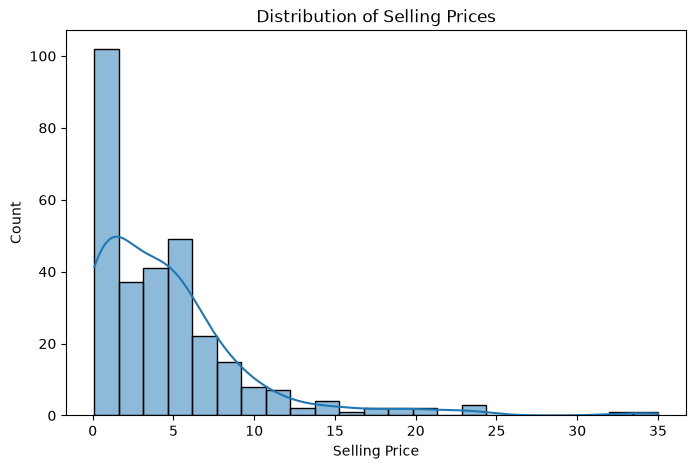

In [64]:
plt.figure(figsize=(8, 5))

sns.histplot(df["Selling_Price"], kde=True)

plt.title("Distribution of Selling Prices")
plt.xlabel("Selling Price")
plt.ylabel("Count")

plt.show()

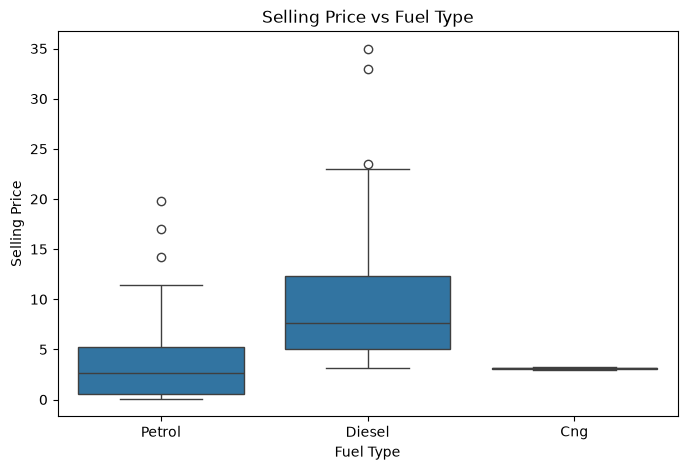

In [65]:
plt.figure(figsize=(8, 5))

sns.boxplot(data=df, x="Fuel_Type", y="Selling_Price")

plt.title("Selling Price vs Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Selling Price")

plt.show()

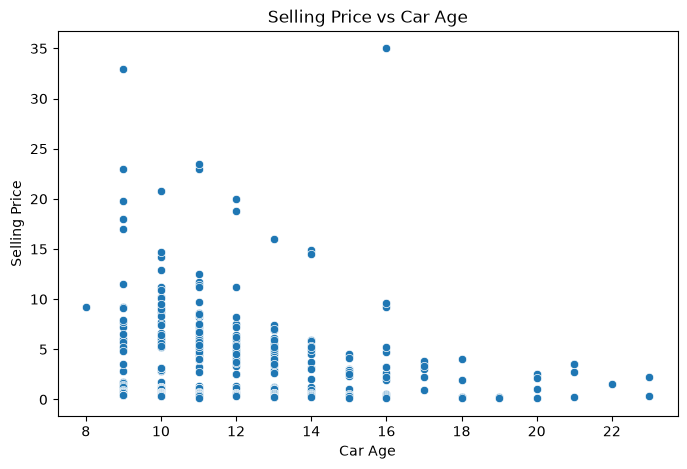

In [66]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Car_Age",
    y="Selling_Price"
)

plt.title("Selling Price vs Car Age")
plt.xlabel("Car Age")
plt.ylabel("Selling Price")

plt.show()

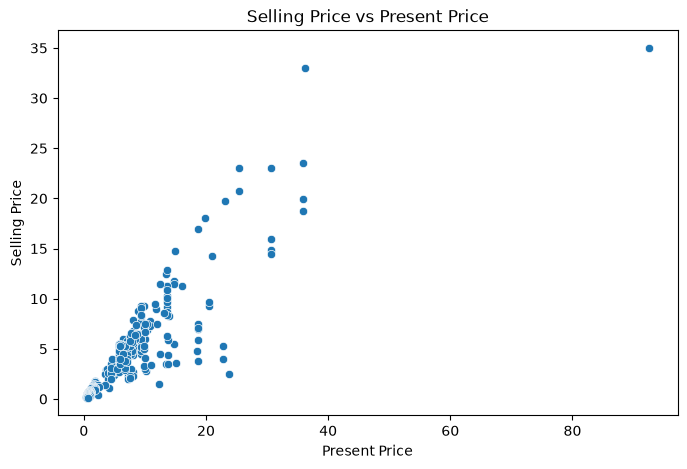

In [67]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Present_Price",
    y="Selling_Price"
)

plt.title("Selling Price vs Present Price")
plt.xlabel("Present Price")
plt.ylabel("Selling Price")


plt.show()


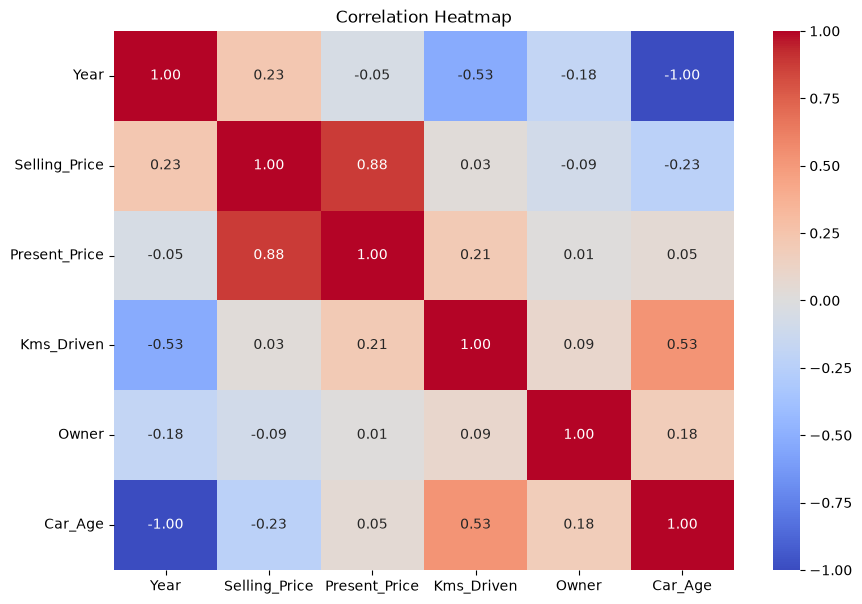

In [68]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    df.select_dtypes(include=np.number).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show()

In [69]:
X = df[
    [
        "Present_Price",
        "Kms_Driven",
        "Car_Age",
        "Fuel_Type",
        "Seller_Type",
        "Transmission",
        "Owner",
        "Brand"
    ]
]

y = df["Selling_Price"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   Present_Price  Kms_Driven  Car_Age Fuel_Type Seller_Type Transmission  \
0           5.59       27000       12    Petrol      Dealer       Manual   
1           9.54       43000       13    Diesel      Dealer       Manual   
2           9.85        6900        9    Petrol      Dealer       Manual   
3           4.15        5200       15    Petrol      Dealer       Manual   
4           6.87       42450       12    Diesel      Dealer       Manual   

   Owner  Brand  
0      0   Ritz  
1      0    Sx4  
2      0   Ciaz  
3      0  Wagon  
4      0  Swift  

Target:
0    3.35
1    4.75
2    7.25
3    2.85
4    4.60
Name: Selling_Price, dtype: float64


In [70]:
X = pd.get_dummies(
    X,
    columns=[
        "Fuel_Type",
        "Seller_Type",
        "Transmission",
        "Brand"
    ],
    drop_first=True
)


X.head()

,Present_Price,Kms_Driven,Car_Age,Owner,Fuel_Type_Diesel,Fuel_Type_Petrol,Seller_Type_Individual,Transmission_Manual,Brand_Activa,Brand_Alto,...,Brand_Suzuki,Brand_Swift,Brand_Sx4,Brand_Tvs,Brand_Um,Brand_Verna,Brand_Vitara,Brand_Wagon,Brand_Xcent,Brand_Yamaha
0,5.59,27000,12,0,False,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
1,9.54,43000,13,0,True,False,False,True,False,False,...,False,False,True,False,False,False,False,False,False,False
2,9.85,6900,9,0,False,True,False,True,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4.15,5200,15,0,False,True,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
4,6.87,42450,12,0,True,False,False,True,False,False,...,False,True,False,False,False,False,False,False,False,False


In [71]:
print("Number of features:", X.shape[1])
print("Number of rows:", X.shape[0])

Number of features: 51
Number of rows: 299


In [72]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (239, 51)
Testing data: (60, 51)


In [73]:
linear_model = LinearRegression()

linear_model.fit(X_train, y_train)

linear_predictions = linear_model.predict(X_test)

print("Linear Regression model trained.")


Linear Regression model trained.


In [74]:
random_forest_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42
)

random_forest_model.fit(X_train, y_train)

rf_predictions = random_forest_model.predict(X_test)

print("Random Forest model trained.")

Random Forest model trained.


In [75]:
gradient_model = GradientBoostingRegressor(
    n_estimators=200,
    random_state=42
)

gradient_model.fit(X_train, y_train)

gradient_predictions = gradient_model.predict(X_test)

print("Gradient Boosting model trained.")

Gradient Boosting model trained.


In [76]:
def evaluate_model(name, actual, predicted):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    r2 = r2_score(actual, predicted)

    print(name)
    print("MAE:", round(mae, 4))
    print("RMSE:", round(rmse, 4))
    print("R2 Score:", round(r2, 4))
    print("-" * 30)

    return mae, rmse, r2

In [77]:
linear_results = evaluate_model(
    "Linear Regression",
    y_test,
    linear_predictions
)

rf_results = evaluate_model(
    "Random Forest",
    y_test,
    rf_predictions
)

gradient_results = evaluate_model(
    "Gradient Boosting",
    y_test,
    gradient_predictions
)

Linear Regression
MAE: 1.3835
RMSE: 2.5699
R2 Score: 0.7438
------------------------------
Random Forest
MAE: 1.3439
RMSE: 3.2168
R2 Score: 0.5985
------------------------------
Gradient Boosting
MAE: 1.141
RMSE: 2.6647
R2 Score: 0.7245
------------------------------


In [78]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        linear_results[0],
        rf_results[0],
        gradient_results[0]
    ],
    "RMSE": [
        linear_results[1],
        rf_results[1],
        gradient_results[1]
    ],
    "R2 Score": [
        linear_results[2],
        rf_results[2],
        gradient_results[2]
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.383500,2.569901,0.743750
1,Random Forest,1.343883,3.216773,0.598513
2,Gradient Boosting,1.141022,2.664715,0.724493


In [79]:
best_model = results.loc[results["R2 Score"].idxmax()]

print("Best Model:", best_model["Model"])
print("R2 Score:", round(best_model["R2 Score"], 4))

Best Model: Linear Regression
R2 Score: 0.7438


In [80]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
0,Present_Price,0.884069
2,Car_Age,0.066025
35,Brand_Land,0.021839
1,Kms_Driven,0.010897
7,Transmission_Manual,0.004884
17,Brand_Corolla,0.002946
6,Seller_Type_Individual,0.002267
32,Brand_Innova,0.001723
16,Brand_City,0.001017
4,Fuel_Type_Diesel,0.000891


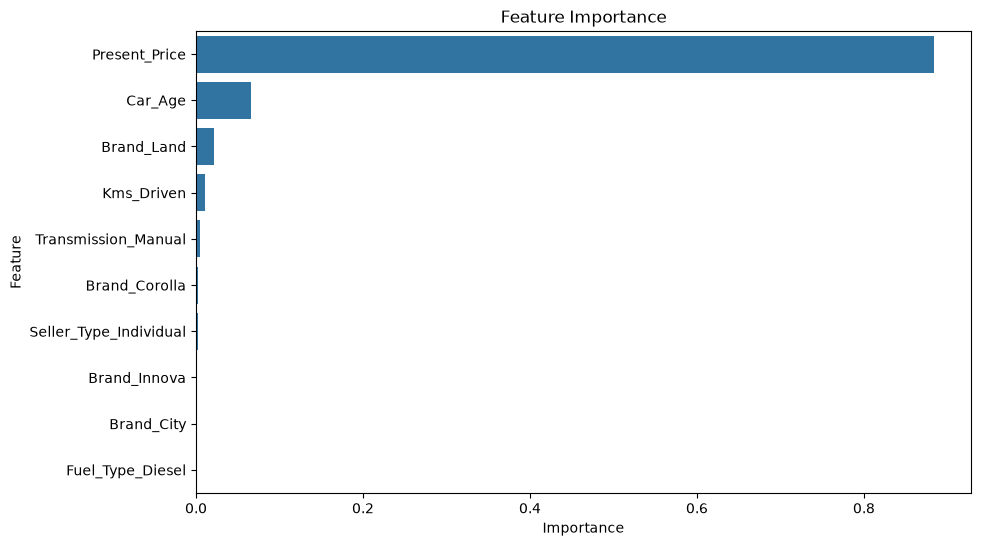

In [81]:
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance.head(10),
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.show()

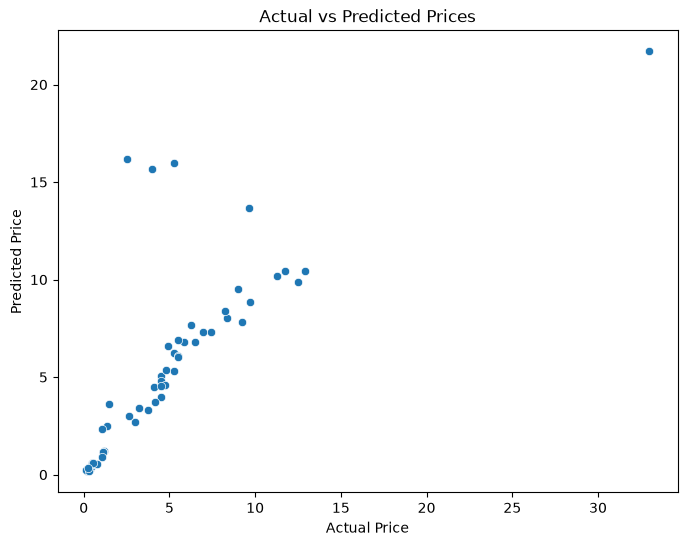

In [82]:
plt.figure(figsize=(8, 6))

sns.scatterplot(
    x=y_test,
    y=rf_predictions
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")

plt.show()

In [83]:
with open("car_price_model.pkl", "wb") as file:
    pickle.dump(random_forest_model, file)

print("Model saved successfully.")


Model saved successfully.
